In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

engine = create_engine(
    "mysql+pymysql://root:@localhost:3309/ecommerce_analytics1"
)

print("Database Connected Successfully!")

query = """
SELECT ROUND(AVG(review_score),2) AS avg_rating
FROM reviews;
"""

avg_rating = pd.read_sql(query, engine)

avg_rating

print(f"Average Rating: {avg_rating.iloc[0,0]}")

Database Connected Successfully!
Average Rating: 4.09


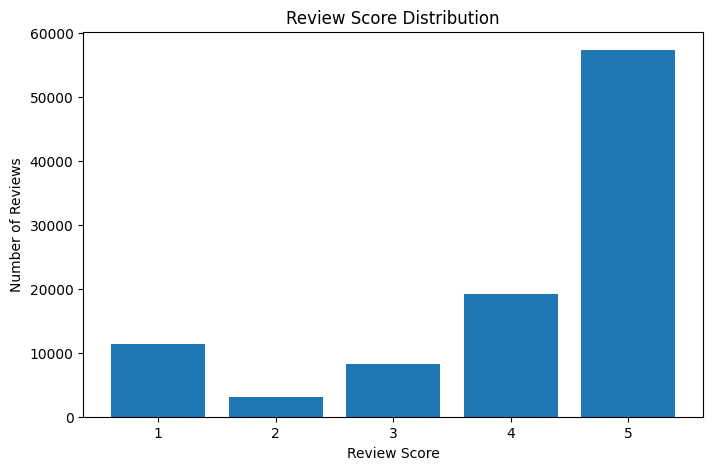

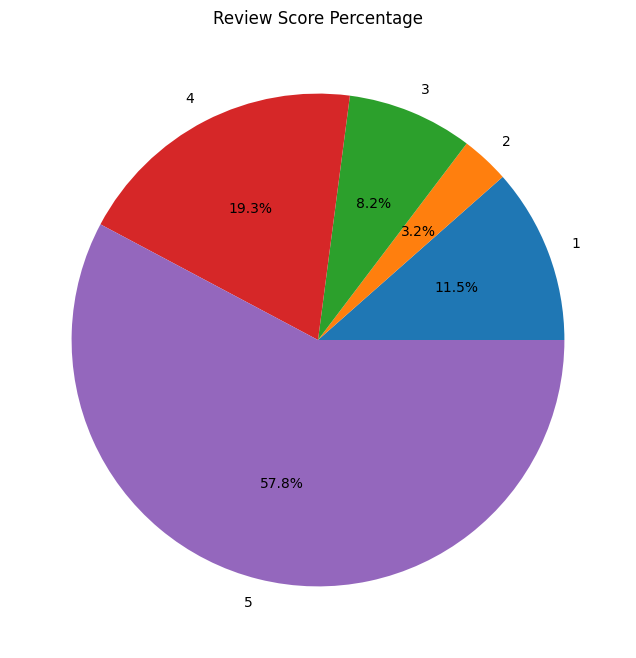

In [2]:
# Rating Distribution

query = """
SELECT
    review_score,
    COUNT(*) AS total_reviews
FROM reviews
GROUP BY review_score
ORDER BY review_score;
"""

rating_dist = pd.read_sql(query, engine)

rating_dist

plt.figure(figsize=(8,5))

plt.bar(
    rating_dist['review_score'],
    rating_dist['total_reviews']
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.show()

# Pie Chart Distribution

plt.figure(figsize=(8,8))

plt.pie(
    rating_dist['total_reviews'],
    labels=rating_dist['review_score'],
    autopct='%1.1f%%'
)

plt.title("Review Score Percentage")

plt.show()

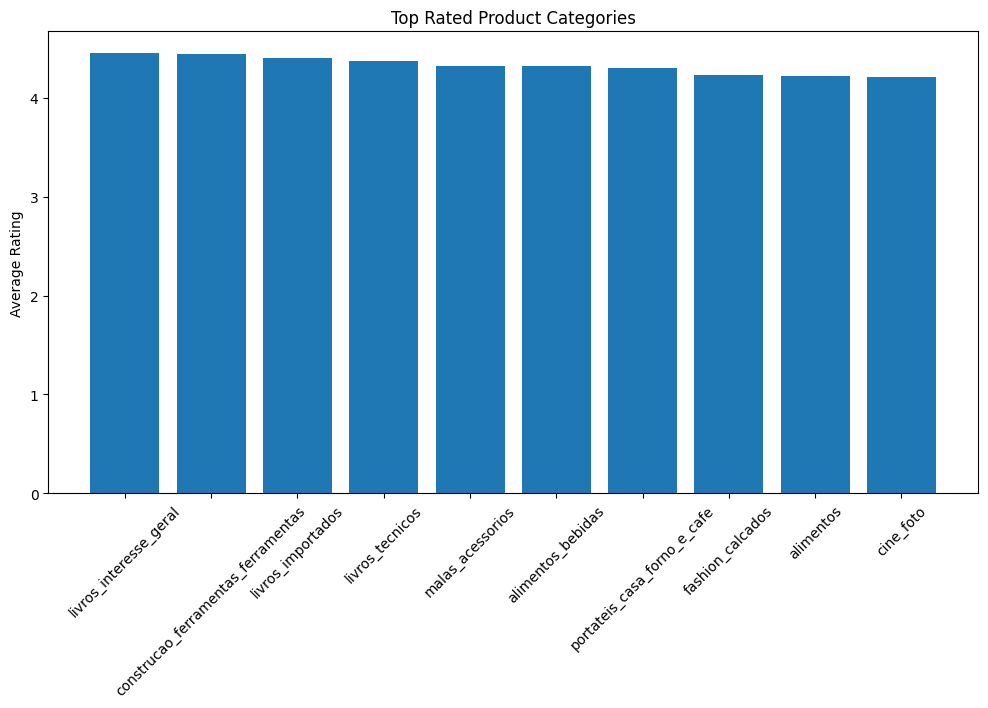

In [3]:
# 5-Star vs 1-Star Reviews

query = """
SELECT
    review_score,
    COUNT(*) AS total_reviews
FROM reviews
WHERE review_score IN (1,5)
GROUP BY review_score;
"""

stars = pd.read_sql(query, engine)

stars

# Best Rated Categories

query = """
SELECT
    p.product_category_name,
    ROUND(AVG(r.review_score),2) AS avg_rating,
    COUNT(*) AS total_reviews
FROM reviews r
JOIN order_items oi
ON r.order_id = oi.order_id
JOIN products p
ON oi.product_id = p.product_id
GROUP BY p.product_category_name
HAVING COUNT(*) > 50
ORDER BY avg_rating DESC
LIMIT 10;
"""

best_categories = pd.read_sql(query, engine)

# best_categories

plt.figure(figsize=(12,6))

plt.bar(
    best_categories['product_category_name'],
    best_categories['avg_rating']
)

plt.xticks(rotation=45)

plt.title("Top Rated Product Categories")
plt.ylabel("Average Rating")

plt.show()

     product_category_name  avg_rating  total_reviews
0        moveis_escritorio        3.49           1687
1  fashion_roupa_masculina        3.64            131
2           telefonia_fixa        3.68            262
3            casa_conforto        3.83            435
4                    audio        3.83            361
product_category_name     object
avg_rating               float64
total_reviews              int64
dtype: object
product_category_name    0
avg_rating               0
total_reviews            0
dtype: int64


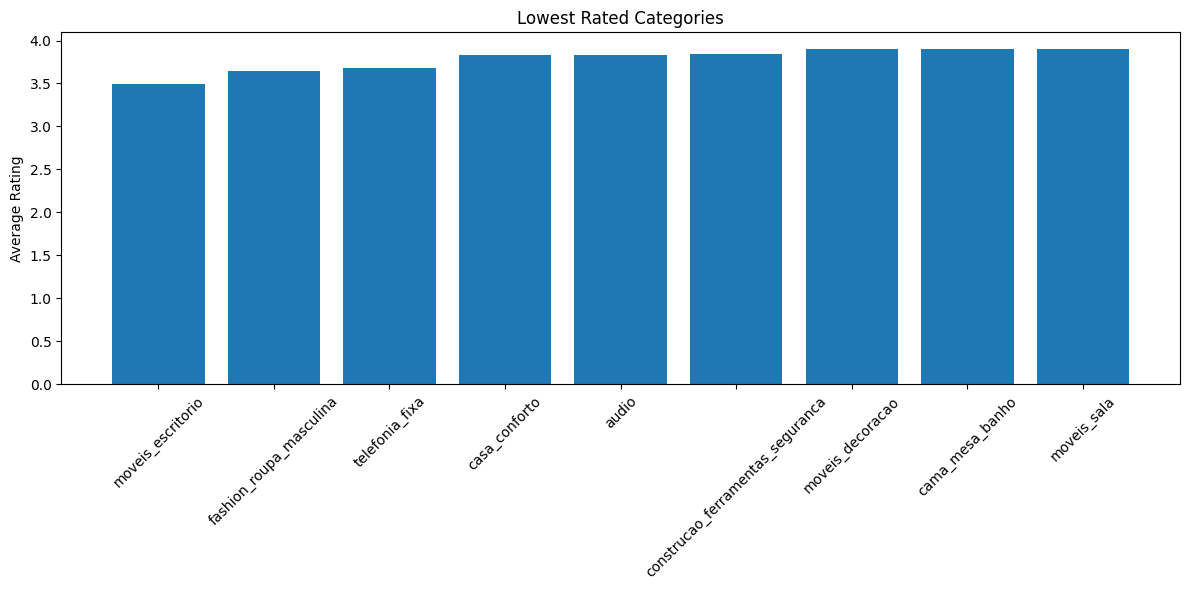

product_category_name     object
avg_rating               float64
total_reviews              int64
dtype: object
     product_category_name  avg_rating  total_reviews
0        moveis_escritorio        3.49           1687
1  fashion_roupa_masculina        3.64            131
2           telefonia_fixa        3.68            262
3            casa_conforto        3.83            435
4                    audio        3.83            361
product_category_name     object
avg_rating               float64
total_reviews              int64
dtype: object


In [11]:
print(worst_categories.head())
print(worst_categories.dtypes)
print(worst_categories.isnull().sum())

worst_categories = worst_categories.dropna(
    subset=['product_category_name']
)

plt.figure(figsize=(12,6))

plt.bar(
    worst_categories['product_category_name'].astype(str),
    worst_categories['avg_rating']
)

plt.xticks(rotation=45)
plt.title("Lowest Rated Categories")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

print(worst_categories.dtypes)

worst_categories['avg_rating'] = pd.to_numeric(
    worst_categories['avg_rating']
)

print(worst_categories.head())
print(worst_categories.dtypes)

In [5]:

query = """
SELECT
    oi.seller_id,
    ROUND(AVG(r.review_score),2) AS avg_rating
FROM reviews r
JOIN order_items oi
ON r.order_id = oi.order_id
GROUP BY oi.seller_id
HAVING COUNT(*) > 20
ORDER BY avg_rating DESC
LIMIT 20;
"""

seller_ratings = pd.read_sql(query, engine)

seller_ratings.head()

# Orders Without Reviews

query = """
SELECT
COUNT(*) AS orders_without_reviews
FROM orders o
LEFT JOIN reviews r
ON o.order_id = r.order_id
WHERE r.review_id IS NULL;
"""

missing_reviews = pd.read_sql(query, engine)

missing_reviews

# Customer Satisfaction Summary

five_star = rating_dist.loc[
    rating_dist['review_score']==5,
    'total_reviews'
].values[0]

total_reviews = rating_dist['total_reviews'].sum()

print("Customer Satisfaction Report")
print("----------------------------")
print("Average Rating:",
      avg_rating.iloc[0,0])

print("5-Star Percentage:",
      round((five_star/total_reviews)*100,2),
      "%")

Customer Satisfaction Report
----------------------------
Average Rating: 4.09
5-Star Percentage: 57.78 %
